# VEP Analysis

In [17]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True
    
import pandas as pd
import polars as pl
import seqpro as sp
import numpy as np
import pooch
from tqdm import tqdm
from pathlib import Path
from tempfile import TemporaryDirectory
import genvarloader as gvl

# Local code
import src.genvarloader as GVL
import src.vep_pipeline as vp
import src.utils as utils
import src.clinvar as cv

# Set environment variable to suppress datetime warnings
os.environ['PYTHONWARNINGS'] = 'ignore::DeprecationWarning:jupyter_client.session'
import warnings
warnings.filterwarnings(action="ignore", message=r"datetime.datetime.utcnow")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import xarray as xr

xr_ds = xr.open_dataset(os.path.join(os.path.expanduser('~'),"projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr"))
xr_ds

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


<xarray.Dataset> Size: 264MB
Dimensions:   (sample: 2548, site: 719, ploid: 2, slot: 9)
Coordinates:
  * sample    (sample) object 20kB 'HG00096' 'HG00097' ... 'NA21143' 'NA21144'
  * slot      (slot) object 72B 'delta_mean' 'delta_abs_mean' ... 'len_seq_mut'
  * ploid     (ploid) object 16B '0' '1'
  * site      (site) object 6kB 'chr22:16953970-17216114_T_C' ... 'chr22:1698...
Data variables:
    flashzoi  (site, sample, ploid, slot) float64 264MB ...

In [20]:
vep_df = xr_ds.where(xr_ds.notnull()).to_dataframe().reset_index()
print(vep_df.shape)
print("sites:",vep_df["site"].nunique())
print("samples:",vep_df["sample"].nunique())
vep_df.head()

(32976216, 5)
sites: 20
samples: 2548


,site,sample,ploid,slot,flashzoi
0,chr22:16953970-17216114_T_C,HG00096,0,delta_mean,-0.000213
1,chr22:16953970-17216114_T_C,HG00096,0,delta_abs_mean,0.000575
2,chr22:16953970-17216114_T_C,HG00096,0,pca_css_mean,0.999985
3,chr22:16953970-17216114_T_C,HG00096,0,time_total,0.105498
4,chr22:16953970-17216114_T_C,HG00096,0,time_run_vep,0.099804


In [9]:
vep_df.groupby("site")["sample"].nunique().describe()

count      20.0
mean     2548.0
std         0.0
min      2548.0
25%      2548.0
50%      2548.0
75%      2548.0
max      2548.0
Name: sample, dtype: float64

In [4]:
vep_df.groupby("slot").describe()

flashzoi                                          \
                    count           mean       std            min   
slot                                                                
delta_abs_mean  3664024.0       0.000334  0.000626       0.000000   
delta_mean      3664024.0       0.000178  0.000339      -0.000298   
len_seq_mut     3664024.0  262144.000000  0.000000  262144.000000   
len_seq_wt      3664024.0  262144.000000  0.000000  262144.000000   
output_length   3664024.0  262144.000000  0.000000  262144.000000   
pca_css_mean       1470.0       0.999992  0.000006       0.999969   
time_run_vep    3664024.0       0.097007  0.002818       0.095120   
time_total      3664024.0       0.101606  0.003527       0.099499   

                                                                            
                          25%            50%            75%            max  
slot                                                                        
delta_abs_mean       0.000000       0.000000       0.000000       0.002053  
delta_mean           0.000000       0.000000       0.000000       0.001263  
len_seq_mut     262144.000000  262144.000000  262144.000000  262144.000000  
len_seq_wt      262144.000000  262144.000000  262144.000000  262144.000000  
output_length   262144.000000  262144.000000  262144.000000  262144.000000  
pca_css_mean         0.999989       0.999990       0.999997       1.000000  
time_run_vep         0.096460       0.096818       0.097305       0.955168  
time_total           0.100991       0.101396       0.101897       1.186299

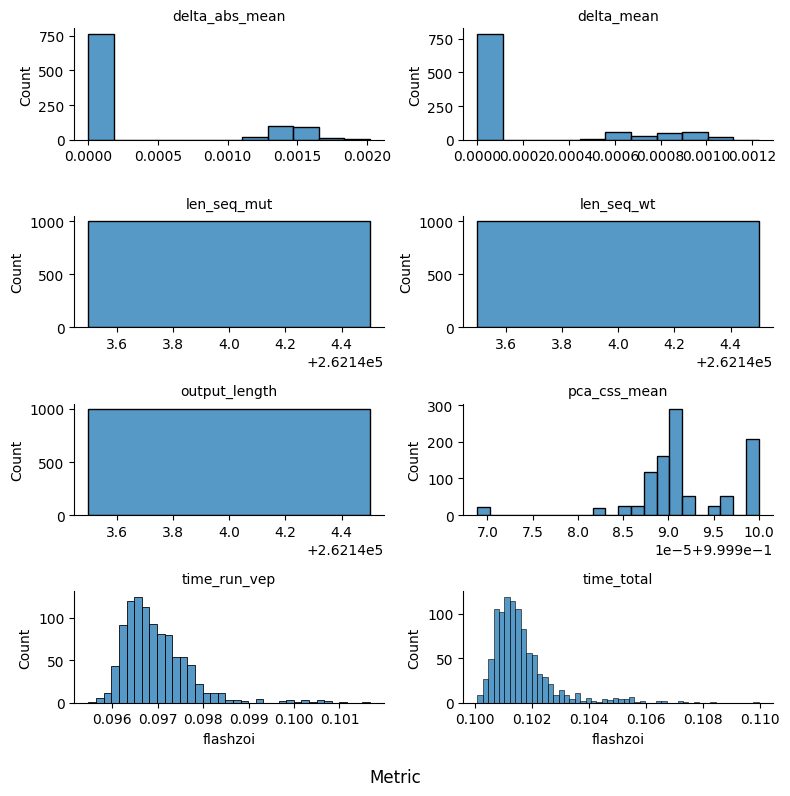

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with subplots for each slot
g = sns.FacetGrid(vep_df.groupby("slot").sample(1000).sort_values("slot"),
                  col="slot",  # Changed from row to col
                  col_wrap=2,  # Added col_wrap to wrap facets
                  height=2, 
                  aspect=2, 
                  margin_titles=True,
                  sharex=False, 
                  sharey=False)
g.map_dataframe(sns.histplot, x="flashzoi")
g.set_titles("{col_name}")
g.fig.supxlabel("Metric")
plt.tight_layout()

## Annotate variants

In [12]:
xr_ds.coords['site'].shape

(719,)

In [13]:
vep_df["site"].apply(lambda x: [x.split("_")[0]])

,site,sample,ploid,slot,flashzoi
0,chr22:16953970-17216114_T_C,HG00096,0,delta_mean,-0.000213
1,chr22:16953970-17216114_T_C,HG00096,0,delta_abs_mean,0.000575
2,chr22:16953970-17216114_T_C,HG00096,0,pca_css_mean,0.999985
3,chr22:16953970-17216114_T_C,HG00096,0,time_total,0.105498
4,chr22:16953970-17216114_T_C,HG00096,0,time_run_vep,0.099804
...,...,...,...,...,...
21797057,chr22:16982510-17244654_G_A,NA21144,1,time_total,0.102443
21797058,chr22:16982510-17244654_G_A,NA21144,1,time_run_vep,0.097832
21797059,chr22:16982510-17244654_G_A,NA21144,1,output_length,262144.000000
21797060,chr22:16982510-17244654_G_A,NA21144,1,len_seq_wt,262144.000000


In [18]:
bed_utr

chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO
str,i64,i64,str,f64,str,str,str,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str
"""1""",1013541,1013542,"""chr1:1013541-1013542_T_C""",2.0,"""T""","""C""","""SO:0001623""","""5_prime_UTR_variant""",0.88579,null,0.90315,1175251,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636"""
"""1""",1055000,1055001,"""chr1:1055000-1055001_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",0.34176,0.33342,0.34345,249353,"""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790"""
"""1""",1055037,1055038,"""chr1:1055037-1055038_T_C""",2.0,"""T""","""C""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.38399,1282674,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055037T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790"""
"""1""",1055137,1055138,"""chr1:1055137-1055138_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.91793,1175253,"""MONDO:MONDO:0014052,MedGen:C38…","""Congenital_myasthenic_syndrome…","""NC_000001.11:g.1055137C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790"""
"""1""",1055153,1055154,"""chr1:1055153-1055154_G_A""",2.0,"""G""","""A""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.12181,1282812,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055153G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""X""",154835925,154835926,"""chrX:154835925-154835926_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.55603,339078,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Hereditary_factor…","""NC_000023.11:g.154835925C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""F8:2157"""
"""X""",154836383,154836384,"""chrX:154836383-154836384_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.00503,352804,"""MONDO:MONDO:0010602,MedGen:C00…","""Hereditary_factor_VIII_deficie…","""NC_000023.11:g.154836383C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""F8:2157"""
"""X""",154837568,154837569,"""chrX:154837568-154837569_G_A""",2.0,"""G""","""A""","""SO:0001624""","""3_prime_UTR_variant""",0.01592,0.00689,0.01272,352166,"""MONDO:MONDO:0010602,MedGen:C00…","""Hereditary_factor_VIII_deficie…","""NC_000023.11:g.154837568G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""F8:2157"""


In [27]:
bed_utr = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz") 
vep_df2 = vep_df.merge(bed_utr.to_pandas(), left_on="site", right_on="name")

In [28]:
vep_df2

,site,sample,ploid,slot,flashzoi,chrom,chromStart,chromEnd,name,score,...,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO
